In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from keras.preprocessing import image
from keras.applications.mobilenet import preprocess_input
from keras.applications import MobileNetV2
from keras.layers import Dense, GlobalAveragePooling2D, Dropout

train = tf.keras.preprocessing.image_dataset_from_directory( #creates training dataset
    "/Users/remboymitch/Downloads/pokemon", #replace with personal device path
    validation_split=0.2,
    subset="training",
    seed = 42,
    image_size=(128, 128),
    batch_size = 32
)
test = tf.keras.preprocessing.image_dataset_from_directory( #creates validation dataset
    "/Users/remboymitch/Downloads/pokemon", #replace with personal device path
    validation_split=0.2,
    subset="validation",
    seed = 42,
    image_size=(128, 128),
    batch_size = 32
)

data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomRotation(.1),
    layers.RandomContrast(0.1)
])

num_classes = 143 #Number of types of Pokemon in dataset
class_names = train.class_names
print(class_names)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
preds = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)
base_model.trainable = False

train = train.map(lambda x, y: (data_aug(x), y))
train = train.map(lambda x, y: (preprocess_input(x), y))
test = test.map(lambda x, y: (preprocess_input(x), y))
AUTOTUNE = tf.data.AUTOTUNE
train = train.shuffle(1000).prefetch(AUTOTUNE)
test = test.cache().prefetch(AUTOTUNE)

optimizer = tf.keras.optimizers.Adam(1e-3)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss_object,
              metrics=['accuracy'])

tf.config.list_physical_devices('GPU')

Found 17261 files belonging to 143 classes.
Using 13809 files for training.
Found 17261 files belonging to 143 classes.
Using 3452 files for validation.
['Abra', 'Aerodactyl', 'Alakazam', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise', 'Bulbasaur', 'Butterfree', 'Caterpie', 'Chansey', 'Charizard', 'Charmander', 'Charmeleon', 'Clefable', 'Clefairy', 'Cloyster', 'Cubone', 'Dewgong', 'Diglett', 'Ditto', 'Dodrio', 'Doduo', 'Dragonair', 'Dragonite', 'Dratini', 'Drowzee', 'Dugtrio', 'Eevee', 'Ekans', 'Electabuzz', 'Electrode', 'Exeggcute', 'Exeggutor', 'Farfetchd', 'Fearow', 'Flareon', 'Gastly', 'Gengar', 'Geodude', 'Gloom', 'Golbat', 'Goldeen', 'Golduck', 'Graveler', 'Grimer', 'Growlithe', 'Gyarados', 'Haunter', 'Hitmonchan', 'Hitmonlee', 'Horsea', 'Hypno', 'Ivysaur', 'Jigglypuff', 'Jolteon', 'Jynx', 'Kabutops', 'Kadabra', 'Kakuna', 'Kangaskhan', 'Kingler', 'Koffing', 'Lapras', 'Lickitung', 'Machamp', 'Machoke', 'Machop', 'Magikarp', 'Magmar', 'Magnemite', 'Magneton'

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Test the model:

Stage 1 Training
Epoch 1/5


2025-11-19 11:10:36.736380: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:36.763191: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:36.841091: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:36.983223: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:37.082794: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:37.312206: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:37.318858: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:37.324594: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:10:37.516987: W tensorflow/core/lib/png/png_io.cc:89] PNG 

432/432 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2781 - loss: 3.5664

2025-11-19 11:11:31.632404: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.670780: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.781152: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.790261: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.808671: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.811089: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.847342: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.853064: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:11:31.864713: W tensorflow/core/lib/png/png_io.cc:89] PNG 

432/432 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.4518 - loss: 2.4597 - val_accuracy: 0.6333 - val_loss: 1.4966
Epoch 2/5


...

  1/432 ━━━━━━━━━━━━━━━━━━━━ 3:35:10 30s/step - accuracy: 0.7812 - loss: 0.7026

2025-11-19 11:14:15.055223: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


432/432 ━━━━━━━━━━━━━━━━━━━━ 64s 79ms/step - accuracy: 0.8211 - loss: 0.6484 - val_accuracy: 0.6993 - val_loss: 1.1531
Epoch 5/5


2025-11-19 11:14:49.442064: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.522343: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.585542: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.598994: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.605088: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.605103: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: cHRM chunk does not match sRGB
2025-11-19 11:14:49.613173: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.673797: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-19 11:14:49.721112: W tensorflow/core/lib/png/png_io.cc:89] PN

432/432 ━━━━━━━━━━━━━━━━━━━━ 66s 82ms/step - accuracy: 0.8430 - loss: 0.5668 - val_accuracy: 0.7031 - val_loss: 1.1704
Stage 2 Training
Model saved successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


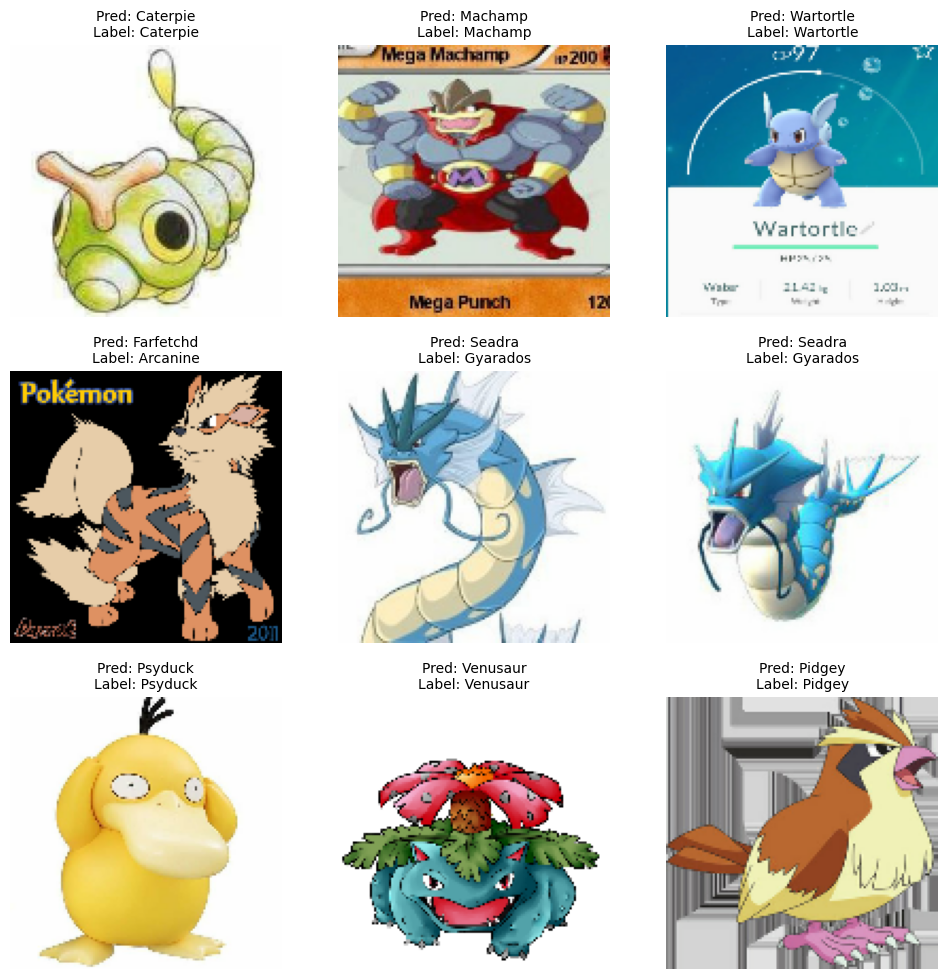

2025-11-19 11:16:01.220455: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("Stage 1 Training")
history=model.fit(
    train,
    epochs=5,
    validation_data=test,
    verbose=1
)

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_object,
    metrics=['accuracy']
)
print("Stage 2 Training")
history_2=model.fit(
    train,
    epochs=5,
    validation_data=test,
    initial_epoch=5,
    verbose=1
)

model.save('pokemon_model.keras')
print("Model saved successfully")

for images, labels in test.take(1):
    preds = model.predict(images)
    pred_classes = preds.argmax(axis=1)
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.axis("off")
        img = images[i].numpy().copy()
        img = (img + 1.0) * 127.5
        img = img.astype("uint8")
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}\nLabel: {true_label}", fontsize=10
        )
    plt.show()
    